# 05 — Anomaly Detection Development

LSTM-Autoencoder pretraining on LogHub HDFS and evaluation.

**Runtime:** Google Colab Pro (T4/L4/A100 GPU recommended)

## Workflow
1. Setup environment and load HDFS data
2. Create model with dynamic `input_dim` from Drain3 templates
3. Pretrain on normal HDFS sequences
4. Plot training curves
5. Calculate threshold on holdout normal data
6. Evaluate on HDFS benchmark (precision/recall/F1)
7. Fine-tune on OTel Demo (placeholder — requires log collection)

In [1]:
%pip install drain3 scikit-learn

  Preparing metadata (setup.py) ... done
  Created wheel for drain3: filename=drain3-0.9.11-py3-none-any.whl size=23998 sha256=c562fde3258b40f3e057e961a7123d3c0588c9258543e46045a2594f3fcfcf7f
  Stored in directory: /root/.cache/pip/wheels/3f/d1/46/58e1747b3d77c4990f838e1c1f610f5aab1a21889cc9bff5c2
Successfully built drain3
  Attempting uninstall: jsonpickle
    Found existing installation: jsonpickle 4.1.1
    Uninstalling jsonpickle-4.1.1:
      Successfully uninstalled jsonpickle-4.1.1
  Attempting uninstall: cachetools
    Found existing installation: cachetools 6.2.6
    Uninstalling cachetools-6.2.6:
      Successfully uninstalled cachetools-6.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyiceberg 0.11.1 requires cachetools<7.0,>=5.5, but you have cachetools 4.2.1 which is incompatible.


In [2]:
# Cell 1: Setup
# If running on Google Colab, uncomment the following lines:

from google.colab import drive
drive.mount('/content/drive', force_remount=True)
# !pip install drain3 scikit-learn

import sys
import os

# Add project root to path (adjust if repo is in a different location)
# For Colab: sys.path.insert(0, '/content/drive/MyDrive/Colab Notebooks/opsagent')
# For local: sys.path.insert(0, '..')
sys.path.insert(0, '/content/drive/MyDrive/Colab Notebooks/opsagent')

import numpy as np
import torch
import matplotlib.pyplot as plt

print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Mounted at /content/drive
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA L4


In [3]:
# Cell 2: Load HDFS data
from src.preprocessing.log_parser import LogParser
from src.preprocessing.loghub_preprocessor import LogHubHDFSPreprocessor

HDFS_DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/opsagent/data/LogHub/HDFS/'  # Adjust for Colab

# Create shared parser (will be reused for OTel fine-tuning later)
parser = LogParser(persistence_path='/content/drive/MyDrive/Colab Notebooks/opsagent/models/drain3/')

preprocessor = LogHubHDFSPreprocessor(
    data_dir=HDFS_DATA_PATH,
    seq_length=10,
    parser=parser,
)
preprocessor.parse()

n_templates = preprocessor.num_templates
print(f'Templates discovered: {n_templates}')
print(f'Blocks parsed: {len(preprocessor._block_sequences)}')

# Get sequences
normal_seqs = preprocessor.get_normal_sequences()
anomalous_seqs = preprocessor.get_anomalous_sequences()
print(f'Normal sequences: {normal_seqs.shape}')
print(f'Anomalous sequences: {anomalous_seqs.shape}')
print(f'Anomaly rate: {len(anomalous_seqs) / (len(normal_seqs) + len(anomalous_seqs)):.4f}')

Templates discovered: 115
Blocks parsed: 575061
Normal sequences: (1608443, 10)
Anomalous sequences: (42785, 10)
Anomaly rate: 0.0259


In [4]:
# Cell 3: Create model and pretrain
from src.anomaly_detection.pretrain_on_loghub import pretrain_on_hdfs

CHECKPOINT_PATH = '/content/drive/MyDrive/Colab Notebooks/opsagent/models/lstm_autoencoder/pretrained_hdfs.pt'

# Pretrain — epochs=50, batch_size=64, lr=0.001, patience=5
model, parser = pretrain_on_hdfs(
    hdfs_data_path=HDFS_DATA_PATH,
    model_save_path=CHECKPOINT_PATH,
    parser=parser,
)

print(f'\nModel parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Checkpoint saved to: {CHECKPOINT_PATH}')

Parsing HDFS.log (this may take several minutes)...
  Templates discovered: 115
  Normal sequences: 1608443
  Train: (1286754, 10, 115), Val: (321689, 10, 115)
Epoch 1/50  train_loss=0.000444  val_loss=0.000078
Epoch 2/50  train_loss=0.000072  val_loss=0.000032
Epoch 3/50  train_loss=0.000043  val_loss=0.000024
Epoch 4/50  train_loss=0.000035  val_loss=0.000061
Epoch 5/50  train_loss=0.000032  val_loss=0.000021
Epoch 6/50  train_loss=0.000028  val_loss=0.000028
Epoch 7/50  train_loss=0.000028  val_loss=0.000022
Epoch 8/50  train_loss=0.000025  val_loss=0.000017
Epoch 9/50  train_loss=0.000025  val_loss=0.000018
Epoch 10/50  train_loss=0.000023  val_loss=0.000027
Epoch 11/50  train_loss=0.000022  val_loss=0.000015
Epoch 12/50  train_loss=0.000020  val_loss=0.000016
Epoch 13/50  train_loss=0.000020  val_loss=0.000014
Epoch 14/50  train_loss=0.000020  val_loss=0.000015
Epoch 15/50  train_loss=0.000019  val_loss=0.000032
Epoch 16/50  train_loss=0.000019  val_loss=0.000014
Epoch 17/50  trai

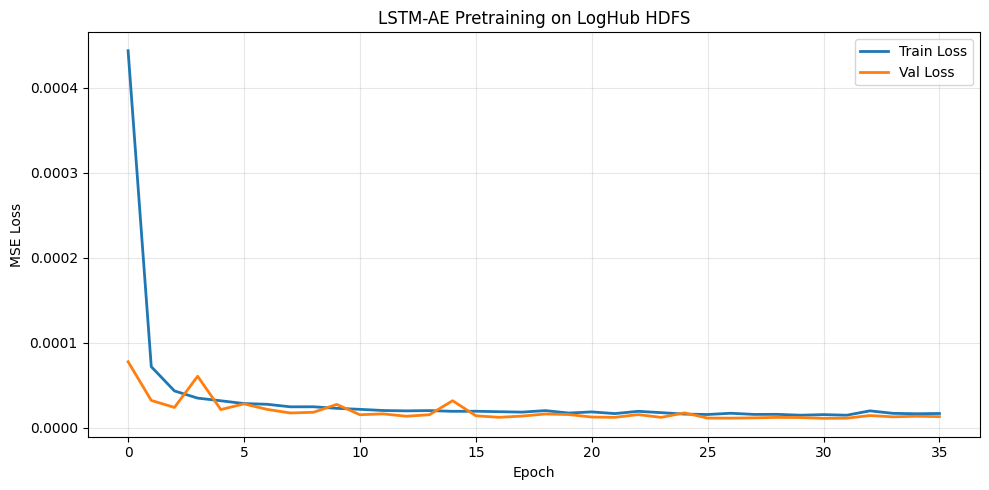

Final train loss: 0.000017
Final val loss:   0.000013
Total epochs:     36


In [3]:
# Cell 4: Plot training curves
CHECKPOINT_PATH = '/content/drive/MyDrive/Colab Notebooks/opsagent/models/lstm_autoencoder/pretrained_hdfs.pt'

checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu')
history = checkpoint['history']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history['train_loss'], label='Train Loss', linewidth=2)
ax.plot(history['val_loss'], label='Val Loss', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('LSTM-AE Pretraining on LogHub HDFS')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/opsagent/docs/images/hdfs_pretraining_curves.png', dpi=150)
plt.show()

print(f'Final train loss: {history["train_loss"][-1]:.6f}')
print(f'Final val loss:   {history["val_loss"][-1]:.6f}')
print(f'Total epochs:     {len(history["train_loss"])}')

In [6]:
# Cell 5: Calculate threshold on holdout normal data
from src.anomaly_detection.pretrain_on_loghub import _one_hot_encode
from src.anomaly_detection.threshold import calculate_threshold
from sklearn.model_selection import train_test_split

# Split normal sequences — use the validation portion for threshold
_, holdout_seqs = train_test_split(normal_seqs, test_size=0.2, random_state=42)

# One-hot encode for model input
holdout_data = _one_hot_encode(holdout_seqs, n_templates)
print(f'Holdout sequences for threshold: {holdout_data.shape}')

# Calculate 95th percentile threshold
device = 'cuda' if torch.cuda.is_available() else 'cpu'
threshold = calculate_threshold(
    model, holdout_data, percentile=95, batch_size=256, device=device
)
print(f'\n95th percentile threshold: {threshold:.6f}')

Holdout sequences for threshold: (321689, 10, 115)
Threshold calculation (p95):
  Samples:   321689
  Mean error: 0.000046
  Std error:  0.000428
  Threshold:  0.000003

95th percentile threshold: 0.000003


In [7]:
# Cell 6: HDFS Benchmark — evaluate on labeled data
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# One-hot encode anomalous sequences
anomalous_data = _one_hot_encode(anomalous_seqs, n_templates)

# Score all sequences
model.eval()
model.to(device)

def get_errors(data, batch_size=256):
    errors = []
    for i in range(0, len(data), batch_size):
        batch = torch.FloatTensor(data[i:i+batch_size]).to(device)
        with torch.no_grad():
            err = model.get_reconstruction_error(batch)
            errors.extend(err.cpu().tolist())
    return np.array(errors)

normal_errors = get_errors(holdout_data)
anomalous_errors = get_errors(anomalous_data)

# Classify using threshold
all_errors = np.concatenate([normal_errors, anomalous_errors])
all_labels = np.concatenate([
    np.zeros(len(normal_errors), dtype=int),
    np.ones(len(anomalous_errors), dtype=int),
])
predictions = (all_errors > threshold).astype(int)

print('HDFS Benchmark Results:')
print(f'  Threshold: {threshold:.6f}')
print(f'  Normal samples:    {len(normal_errors)}')
print(f'  Anomalous samples: {len(anomalous_errors)}')
print()
print(classification_report(all_labels, predictions, target_names=['Normal', 'Anomaly']))

f1 = f1_score(all_labels, predictions)
precision = precision_score(all_labels, predictions)
recall = recall_score(all_labels, predictions)
print(f'F1: {f1:.4f}  Precision: {precision:.4f}  Recall: {recall:.4f}')

HDFS Benchmark Results:
  Threshold: 0.000003
  Normal samples:    321689
  Anomalous samples: 42785

              precision    recall  f1-score   support

      Normal       0.94      0.95      0.95    321689
     Anomaly       0.60      0.56      0.58     42785

    accuracy                           0.90    364474
   macro avg       0.77      0.75      0.76    364474
weighted avg       0.90      0.90      0.90    364474

F1: 0.5771  Precision: 0.5978  Recall: 0.5578


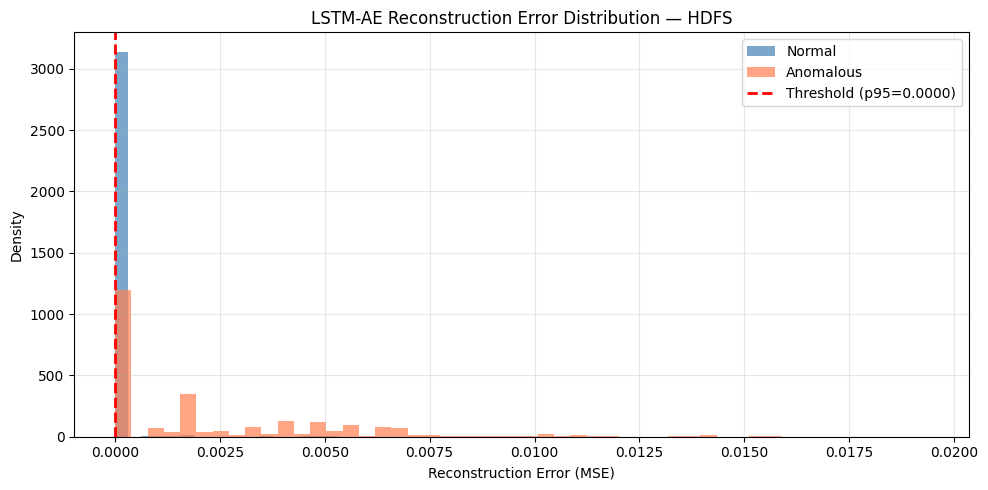

In [8]:
# Cell 7: Error distribution visualization
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(normal_errors, bins=50, alpha=0.7, label='Normal', color='steelblue', density=True)
ax.hist(anomalous_errors, bins=50, alpha=0.7, label='Anomalous', color='coral', density=True)
ax.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold (p95={threshold:.4f})')
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Density')
ax.set_title('LSTM-AE Reconstruction Error Distribution — HDFS')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/opsagent/docs/images/hdfs_error_distribution.png', dpi=150)
plt.show()

In [4]:
# Cell 8: Fine-tune on OTel Demo
import json

OTEL_SPLITS_PATH = '/content/drive/MyDrive/Colab Notebooks/opsagent/data/splits/otel/'
PRETRAINED_PATH = '/content/drive/MyDrive/Colab Notebooks/opsagent/models/lstm_autoencoder/pretrained_hdfs.pt'
FINETUNED_PATH = '/content/drive/MyDrive/Colab Notebooks/opsagent/models/lstm_autoencoder/finetuned_otel.pt'

# Load preprocessed data
train_data = np.load(OTEL_SPLITS_PATH + 'train.npy')
val_data = np.load(OTEL_SPLITS_PATH + 'val.npy')
with open(OTEL_SPLITS_PATH + 'metadata.json') as f:
    meta = json.load(f)

input_dim = meta['input_dim']
print(f'Train: {train_data.shape}')
print(f'Val:   {val_data.shape}')
print(f'Input dim: {input_dim}')

# Fine-tune
from src.anomaly_detection.pretrain_on_loghub import finetune_on_otel_demo

otel_data = {
    'train': train_data,
    'val': val_data,
    'input_dim': input_dim,
}

finetuned_model = finetune_on_otel_demo(
    pretrained_model_path=PRETRAINED_PATH,
    otel_data=otel_data,
    model_save_path=FINETUNED_PATH,
)

print(f'\nFine-tuned model parameters: {sum(p.numel() for p in finetuned_model.parameters()):,}')

Train: (1144, 10, 54)
Val:   (286, 10, 54)
Input dim: 54
Input dimensions differ — loading compatible weights only.
_load_compatible_weights: loaded 20/24 tensors.
  Transferred: encoder, decoder, latent projection weights.
  Skipped: embedding, output_layer (input_dim mismatch).
Epoch 1/200  train_loss=0.567364  val_loss=0.417081
Epoch 2/200  train_loss=0.535994  val_loss=0.394276
Epoch 3/200  train_loss=0.508922  val_loss=0.372979
Epoch 4/200  train_loss=0.487938  val_loss=0.360181
Epoch 5/200  train_loss=0.474821  val_loss=0.350225
Epoch 6/200  train_loss=0.462520  val_loss=0.341118
Epoch 7/200  train_loss=0.451882  val_loss=0.333007
Epoch 8/200  train_loss=0.443911  val_loss=0.325766
Epoch 9/200  train_loss=0.434802  val_loss=0.320954
Epoch 10/200  train_loss=0.427809  val_loss=0.317067
Epoch 11/200  train_loss=0.423496  val_loss=0.309405
Epoch 12/200  train_loss=0.417883  val_loss=0.305093
Epoch 13/200  train_loss=0.413844  val_loss=0.302078
Epoch 14/200  train_loss=0.408813  val_

In [5]:
# Cell 9: Calculate threshold on fine-tuned model
from src.anomaly_detection.threshold import calculate_threshold

device = 'cuda' if torch.cuda.is_available() else 'cpu'
threshold_finetuned = calculate_threshold(
    finetuned_model, val_data, percentile=95, batch_size=256, device=device
)
print(f'Fine-tuned 95th percentile threshold: {threshold_finetuned:.6f}')

Threshold calculation (p95):
  Samples:   286
  Mean error: 0.134209
  Std error:  0.278646
  Threshold:  0.252718
Fine-tuned 95th percentile threshold: 0.252718


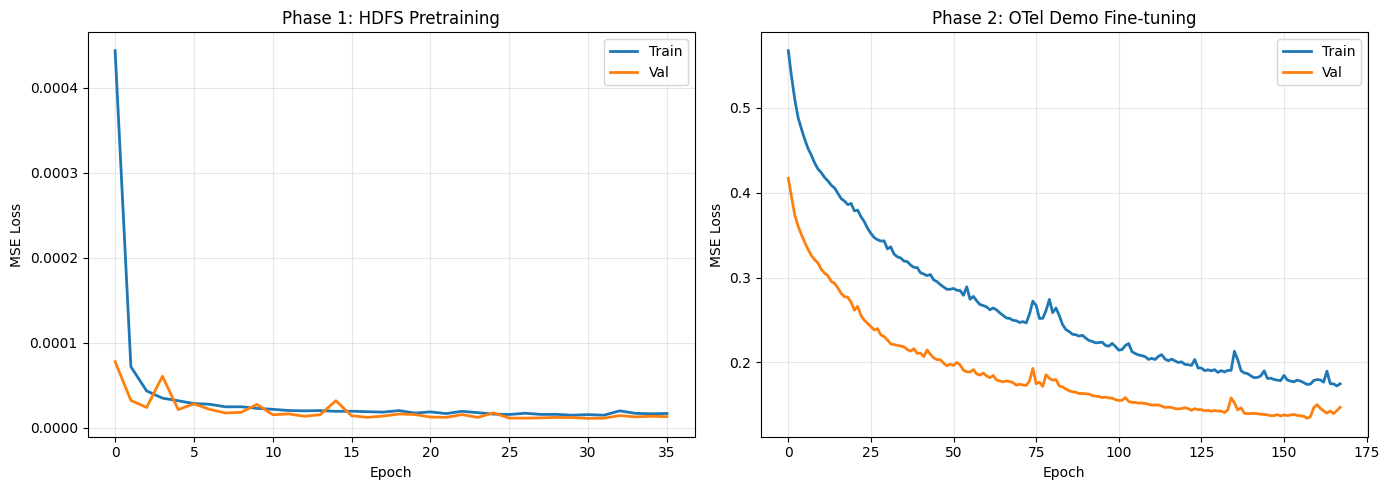

Fine-tune epochs: 168
Final train loss: 0.174721
Final val loss:   0.146976


In [6]:
# Cell 10: Plot pretrain + fine-tune training curves
checkpoint_ft = torch.load(FINETUNED_PATH, map_location='cpu')
history_ft = checkpoint_ft['history']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pretraining curves
axes[0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0].plot(history['val_loss'], label='Val', linewidth=2)
axes[0].set_title('Phase 1: HDFS Pretraining')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Fine-tuning curves
axes[1].plot(history_ft['train_loss'], label='Train', linewidth=2)
axes[1].plot(history_ft['val_loss'], label='Val', linewidth=2)
axes[1].set_title('Phase 2: OTel Demo Fine-tuning')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/opsagent/docs/images/finetune_training_curves.png', dpi=150)
plt.show()

print(f'Fine-tune epochs: {len(history_ft["train_loss"])}')
print(f'Final train loss: {history_ft["train_loss"][-1]:.6f}')
print(f'Final val loss:   {history_ft["val_loss"][-1]:.6f}')

Model loaded: input_dim=54, device=cuda
Validation data: (286, 10, 54)

Normal data errors: mean=0.134209, std=0.278646
Threshold (p95): 0.252718
Synthetic anomalous sequences: (285, 10, 54)
Anomalous data errors: mean=4.492180, std=2.050301

=== OTel Fine-tuned Model Benchmark (Synthetic Anomalies) ===
Normal samples:    286
Anomalous samples: 285
Threshold:         0.252718
Precision:         0.9500
Recall:            1.0000
F1-Score:          0.9744

              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97       286
     Anomaly       0.95      1.00      0.97       285

    accuracy                           0.97       571
   macro avg       0.97      0.97      0.97       571
weighted avg       0.98      0.97      0.97       571

Per-type detection rate:
  CPU Spike           : 95/95 (100.0%)
  Memory Spike        : 95/95 (100.0%)
  Network Error       : 95/95 (100.0%)


/tmp/ipykernel_11588/2070996801.py:143: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=box_df, x='Type', y='Error', ax=axes[1], palette='Set2')


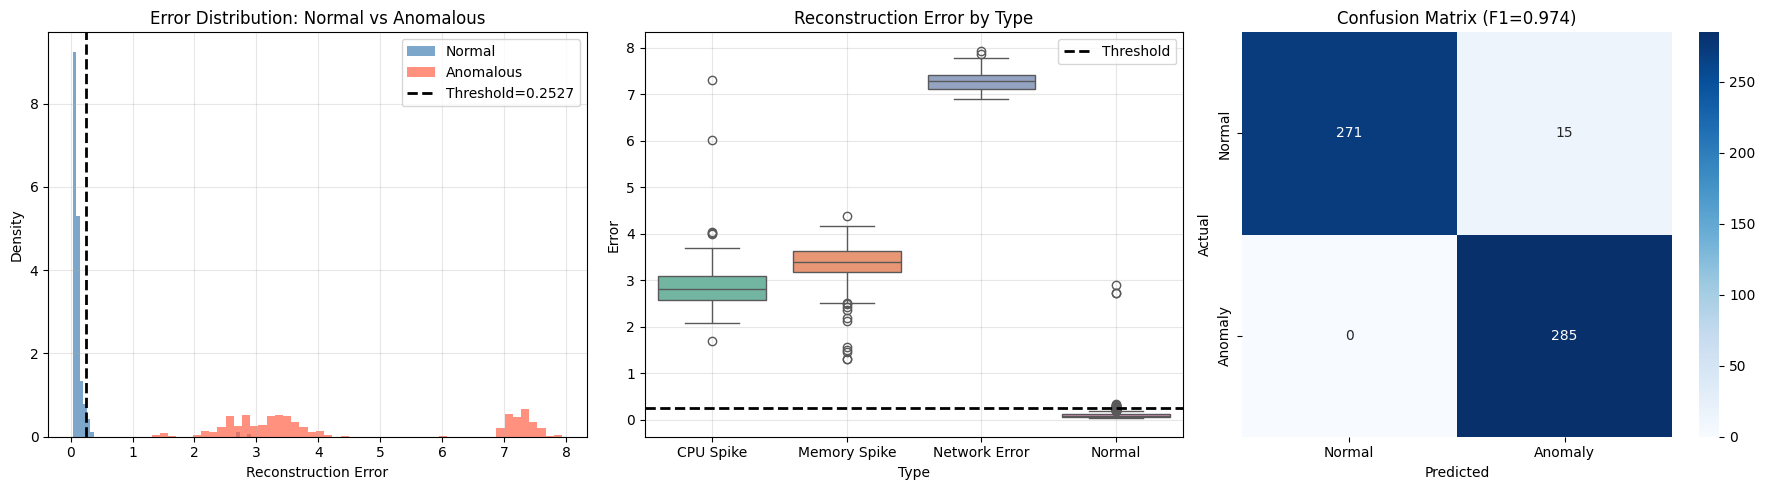

In [3]:
# Cell 11: OTel Fine-tuned Model Benchmark (Synthetic Anomalies)
# Self-contained — only requires Cell 1 (pip install) and Cell 2 (setup/imports).

import json
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

from src.anomaly_detection.lstm_autoencoder import LSTMAutoencoder
from src.anomaly_detection.threshold import calculate_threshold

# ── 1. Load checkpoint and validation data ────────────────────────────────────
FINETUNED_PATH = '/content/drive/MyDrive/Colab Notebooks/opsagent/models/lstm_autoencoder/finetuned_otel.pt'
OTEL_SPLITS_PATH = '/content/drive/MyDrive/Colab Notebooks/opsagent/data/splits/otel/'

val_data = np.load(OTEL_SPLITS_PATH + 'val.npy')
with open(OTEL_SPLITS_PATH + 'metadata.json') as f:
    meta = json.load(f)

input_dim = meta['input_dim']
checkpoint = torch.load(FINETUNED_PATH, map_location='cpu')
model = LSTMAutoencoder(input_dim=input_dim)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)
print(f'Model loaded: input_dim={input_dim}, device={device}')
print(f'Validation data: {val_data.shape}')

# ── 2. Compute reconstruction errors on normal data ──────────────────────────
def get_reconstruction_errors(model, data, device, batch_size=256):
    """Compute per-sequence mean reconstruction error."""
    model.eval()
    errors = []
    with torch.no_grad():
        for i in range(0, len(data), batch_size):
            batch = torch.FloatTensor(data[i:i+batch_size]).to(device)
            recon = model(batch)
            mse = ((batch - recon) ** 2).mean(dim=(1, 2))
            errors.extend(mse.cpu().numpy().tolist())
    return np.array(errors)

normal_errors = get_reconstruction_errors(model, val_data, device)
threshold = np.percentile(normal_errors, 95)
print(f'\nNormal data errors: mean={normal_errors.mean():.6f}, std={normal_errors.std():.6f}')
print(f'Threshold (p95): {threshold:.6f}')

# ── 3. Generate synthetic anomalous sequences ─────────────────────────────────
# Feature layout: log(12) + cpu(7) + mem_ws(7) + net_rx(7) + net_tx(7) + rx_err(7) + tx_err(7) = 54
# Metric feature indices (after 12 log features):
CPU_START = 12       # cpu_usage_rate stats (7 features)
MEM_START = 19       # memory_working_set_bytes stats (7 features)
RX_ERR_START = 40    # network_rx_errors_rate stats (7 features)
TX_ERR_START = 47    # network_tx_errors_rate stats (7 features)

rng = np.random.default_rng(42)
n_anomalies_per_type = len(val_data) // 3  # ~95 per type, ~285 total

anomalous_sequences = []
anomaly_labels = []

# Type 1: CPU spike — set CPU features to +5σ
cpu_spike = val_data[:n_anomalies_per_type].copy()
cpu_spike[:, :, CPU_START:CPU_START+7] += 5.0  # +5σ in normalized space
anomalous_sequences.append(cpu_spike)
anomaly_labels.extend(['cpu_spike'] * len(cpu_spike))

# Type 2: Memory spike — set memory features to +5σ
mem_spike = val_data[n_anomalies_per_type:2*n_anomalies_per_type].copy()
mem_spike[:, :, MEM_START:MEM_START+7] += 5.0
anomalous_sequences.append(mem_spike)
anomaly_labels.extend(['memory_spike'] * len(mem_spike))

# Type 3: Network error spike — set zero-variance error features to non-zero
net_err_spike = val_data[2*n_anomalies_per_type:3*n_anomalies_per_type].copy()
net_err_spike[:, :, RX_ERR_START:RX_ERR_START+7] = 5.0  # Set to 5σ (was always 0)
net_err_spike[:, :, TX_ERR_START:TX_ERR_START+7] = 5.0
anomalous_sequences.append(net_err_spike)
anomaly_labels.extend(['network_error'] * len(net_err_spike))

anomalous_data = np.concatenate(anomalous_sequences, axis=0)
print(f'Synthetic anomalous sequences: {anomalous_data.shape}')

# ── 4. Compute errors on anomalous data ──────────────────────────────────────
anomalous_errors = get_reconstruction_errors(model, anomalous_data, device)
print(f'Anomalous data errors: mean={anomalous_errors.mean():.6f}, std={anomalous_errors.std():.6f}')

# ── 5. Classification metrics ────────────────────────────────────────────────
all_errors = np.concatenate([normal_errors, anomalous_errors])
y_true = np.array([0] * len(normal_errors) + [1] * len(anomalous_errors))
y_pred = (all_errors > threshold).astype(int)

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f'\n=== OTel Fine-tuned Model Benchmark (Synthetic Anomalies) ===')
print(f'Normal samples:    {len(normal_errors)}')
print(f'Anomalous samples: {len(anomalous_errors)}')
print(f'Threshold:         {threshold:.6f}')
print(f'Precision:         {precision:.4f}')
print(f'Recall:            {recall:.4f}')
print(f'F1-Score:          {f1:.4f}')
print(f'\n{classification_report(y_true, y_pred, target_names=["Normal", "Anomaly"])}')

# Per-type recall
type_starts = [0, n_anomalies_per_type, 2 * n_anomalies_per_type]
type_names = ['CPU Spike', 'Memory Spike', 'Network Error']
print('Per-type detection rate:')
for name, start in zip(type_names, type_starts):
    type_errors = anomalous_errors[start:start + n_anomalies_per_type]
    detected = (type_errors > threshold).sum()
    print(f'  {name:20s}: {detected}/{len(type_errors)} ({detected/len(type_errors)*100:.1f}%)')

# ── 6. Visualizations ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Error distribution histogram
axes[0].hist(normal_errors, bins=50, alpha=0.7, label='Normal', color='steelblue', density=True)
axes[0].hist(anomalous_errors, bins=50, alpha=0.7, label='Anomalous', color='tomato', density=True)
axes[0].axvline(threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold={threshold:.4f}')
axes[0].set_xlabel('Reconstruction Error')
axes[0].set_ylabel('Density')
axes[0].set_title('Error Distribution: Normal vs Anomalous')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Per-type box plot
type_data = []
type_labels_plot = []
for name, start in zip(type_names, type_starts):
    errs = anomalous_errors[start:start + n_anomalies_per_type]
    type_data.extend(errs.tolist())
    type_labels_plot.extend([name] * len(errs))
type_data.extend(normal_errors.tolist())
type_labels_plot.extend(['Normal'] * len(normal_errors))

import pandas as pd
box_df = pd.DataFrame({'Error': type_data, 'Type': type_labels_plot})
sns.boxplot(data=box_df, x='Type', y='Error', ax=axes[1], palette='Set2')
axes[1].axhline(threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold')
axes[1].set_title('Reconstruction Error by Type')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'], ax=axes[2])
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
axes[2].set_title(f'Confusion Matrix (F1={f1:.3f})')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/opsagent/docs/images/otel_finetune_benchmark.png', dpi=150)
plt.show()